In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import FunctionTransformer

from sklearn.base import BaseEstimator, TransformerMixin


from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans

In [2]:
housing=pd.read_csv('files/housing.csv')

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

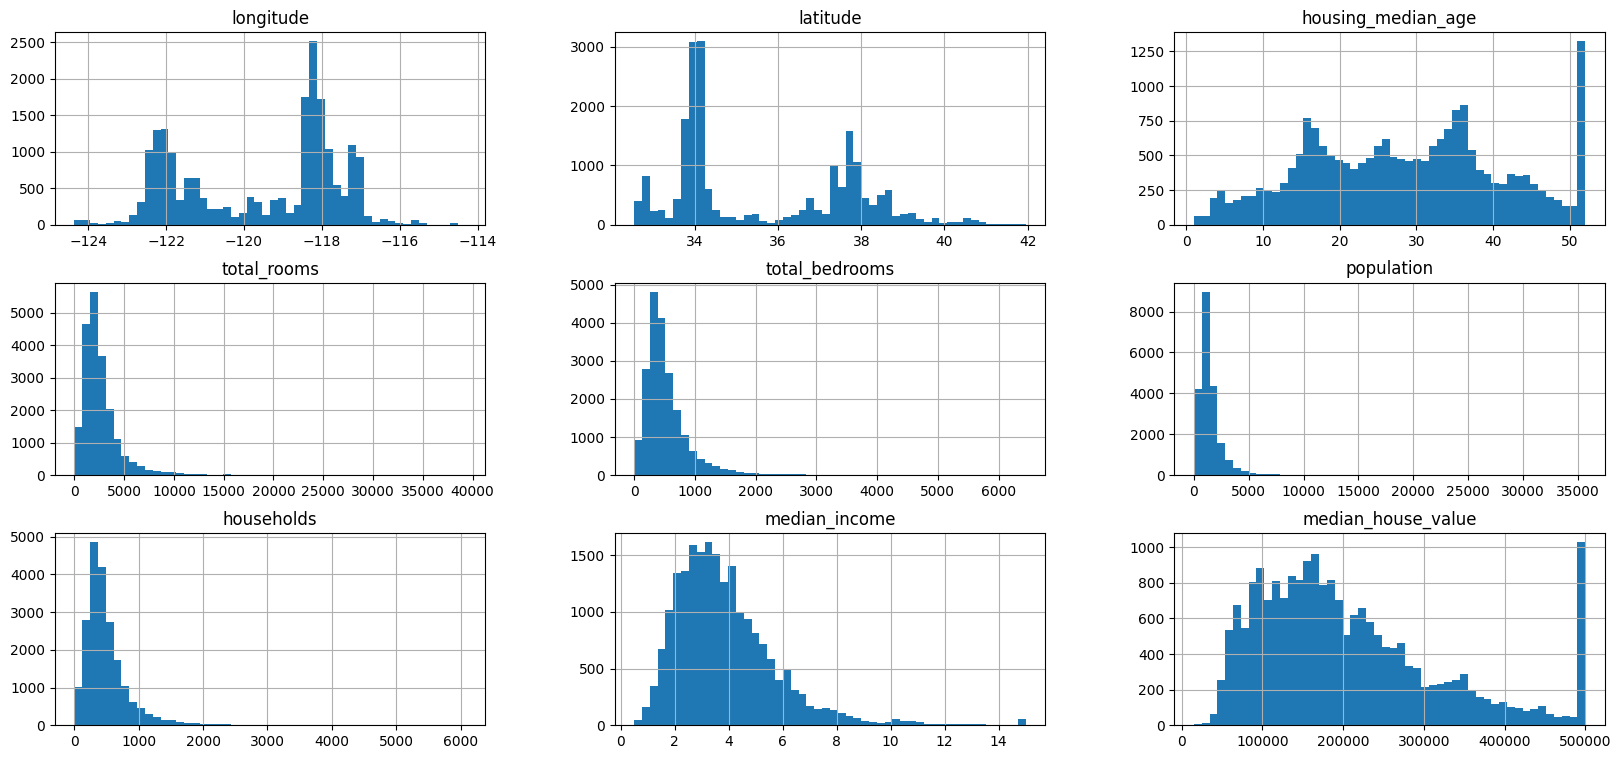

In [3]:
housing.hist(bins=50,figsize=(20,9))

## Required Preprocessing
1. missing_values
2. scale
3. log Transformation -> for power law distribution
4. similarity to cluster -> similarity with cluster centres in data
5. multimodes -> similarity with peaks using rbf_kernel
6. num_to_category -> onehot
7. Bucketization -> num labels for normal distribution, and categorical value for multimodes distribution

In [9]:
df_new=housing[housing['housing_median_age']!=housing['housing_median_age'].max()]
df_new=df_new[housing['median_house_value']!=housing['median_house_value'].max()]
df_new

C:\Users\visha\AppData\Local\Temp\ipykernel_3732\2691221700.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_new=df_new[housing['median_house_value']!=housing['median_house_value'].max()]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,NEAR BAY
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

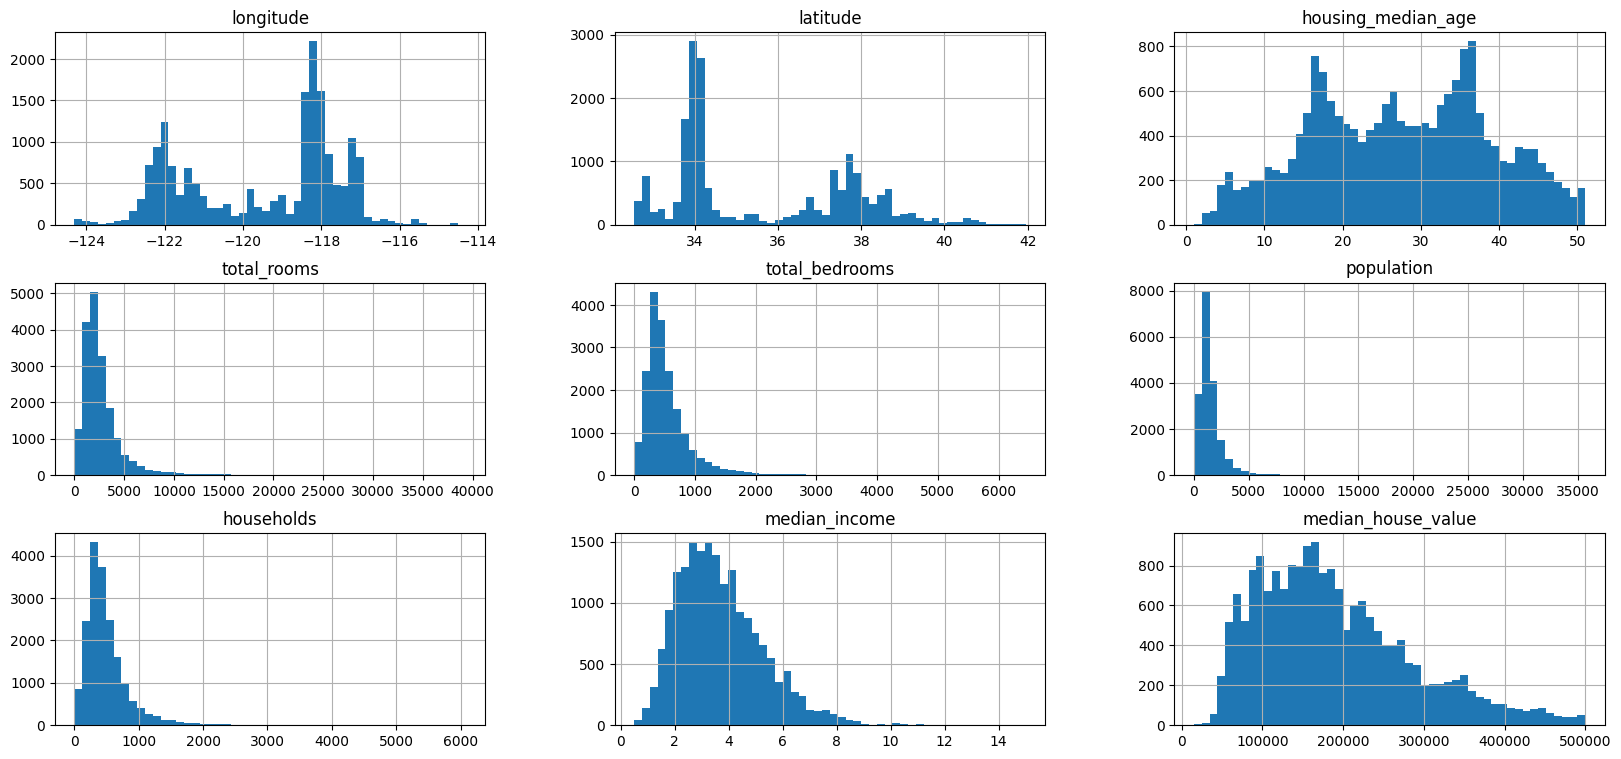

In [10]:
df_new.hist(bins=50,figsize=(20,9))

In [ ]:
housing=df_new

### num_pipeline

In [ ]:
#num_pipeline
housing_num=housing.select_dtypes(np.number)
num_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy="median")),
    ("scale",StandardScaler(with_mean=True))
])

### cat_pipeline

In [ ]:
### cat_pipeline
cat_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy='most_frequent')),
    ("onehot",OneHotEncoder())
])

### Ratio Transformation

In [ ]:
### Ratio Transformation
def ratio(X):
    return X[:,[0]]/X[:,[1]]
def column_name(function_transformer,get_features_in):
    return ["ratio"]

ratio_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("ratio",FunctionTransformer(func=ratio,feature_names_out=column_name)),
    ("standardscaler",StandardScaler(with_mean=True))
])

### cluster similarity

In [ ]:
# cluster similarity

from sklearn.cluster import KMeans


class Similarity4Cluster(BaseEstimator, TransformerMixin):

    def __init__(self, n_clusters=10, gamma=0.1, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, sample_weight=None, y=None):
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )
        self.kmeans_.fit(X, sample_weight=sample_weight)

        return self

    def transform(self, X):
        return rbf_kernel(
            X,
            self.kmeans_.cluster_centers_,
            gamma=self.gamma
        )

    def get_feature_names_out(self, name=None):
        return [
            f"similarity with {i+1} cluster"
            for i in range(self.n_clusters)
        ]

#### log_pipeline

In [22]:
#log transformation
log_pipeline=Pipeline([
    ("simpleimputer",SimpleImputer(strategy="median")),
    ("log",FunctionTransformer(func=np.log,feature_names_out="one-to-one")),
    ("standardscaler",StandardScaler(with_mean=True))
])

#### multimodes distribution

In [23]:
# multimodes distribution

def similarity_clms(function_transformer, get_features_in):
    return ["Similarity with Housing age: 35"]


simil = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("similarity",
     FunctionTransformer(
         func=rbf_kernel,
         kw_args=dict(Y=[[35]], gamma=0.1),
         feature_names_out=similarity_clms
     )
    ),
    ("standardscaler", StandardScaler())
])

### Final Preprocessing

In [41]:
# Final Preprocessing
preprocessing=ColumnTransformer([
    ("bedrooms",ratio_pipeline,['total_bedrooms','total_rooms']),
    ("rooms_per_house",ratio_pipeline,["total_rooms","households"]),
    ("people_per_house",ratio_pipeline,["population","households"]),
    ("log",log_pipeline,["total_bedrooms","total_rooms","population","households","median_income"]),
    ("geo",Similarity4Cluster(),["latitude","longitude"]),
    ("cat",cat_pipeline,["ocean_proximity"]),
    ("simil",simil,['housing_median_age']),
    ("pass","passthrough",["median_house_value"])
],remainder=num_pipeline)

In [32]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [42]:
arr=preprocessing.fit_transform(housing)
arr

array([[-1.12048440e+00,  6.83183840e-01, -5.11536777e-02, ...,
         0.00000000e+00, -4.82879585e-01,  4.52600000e+05],
       [-9.68986533e-01,  3.64089366e-01, -9.23801067e-02, ...,
         0.00000000e+00, -5.65655246e-01,  3.58500000e+05],
       [ 7.50397218e-01, -4.67457897e-01, -1.00052692e-01, ...,
         0.00000000e+00, -5.43096254e-01,  2.26700000e+05],
       ...,
       [ 8.17115871e-03, -7.75991256e-02, -7.24202409e-02, ...,
         0.00000000e+00, -5.65655256e-01,  9.23000000e+04],
       [ 8.58390810e-02, -2.45713355e-02, -9.11436903e-02, ...,
         0.00000000e+00, -5.65655256e-01,  8.47000000e+04],
       [ 1.07108860e-01, -5.65650160e-02, -4.54721001e-02, ...,
         0.00000000e+00, -5.65655256e-01,  8.94000000e+04]],
      shape=(18572, 25))

In [43]:
clm=preprocessing.get_feature_names_out()
clm

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__similarity with 1 cluster',
       'geo__similarity with 2 cluster', 'geo__similarity with 3 cluster',
       'geo__similarity with 4 cluster', 'geo__similarity with 5 cluster',
       'geo__similarity with 6 cluster', 'geo__similarity with 7 cluster',
       'geo__similarity with 8 cluster', 'geo__similarity with 9 cluster',
       'geo__similarity with 10 cluster',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN',
       'simil__Similarity with Housing age: 35',
       'pass__median_house_value'], dtype=object)

In [45]:
df=pd.DataFrame(arr,columns=clm)
df

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__similarity with 1 cluster,geo__similarity with 2 cluster,...,geo__similarity with 8 cluster,geo__similarity with 9 cluster,geo__similarity with 10 cluster,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,simil__Similarity with Housing age: 35,pass__median_house_value
0,-1.120484,0.683184,-0.051154,-1.690992,-1.166625,-1.760937,-1.611414,2.059417,0.042658,0.997289,...,0.951323,0.208444,0.372778,0.0,0.0,0.0,1.0,0.0,-0.482880,452600.0
1,-0.968987,0.364089,-0.092380,1.303991,1.654793,0.993679,1.431735,2.052898,0.043677,0.996517,...,0.954284,0.212038,0.367560,0.0,0.0,0.0,1.0,0.0,-0.565655,358500.0
2,0.750397,-0.467458,-0.100053,0.594907,0.273804,0.049588,0.535048,-1.098130,0.042938,0.996586,...,0.953875,0.210118,0.367679,0.0,0.0,0.0,1.0,0.0,-0.543096,226700.0
3,0.625400,-0.489570,-0.043329,-0.595926,-0.840721,-0.702145,-0.588617,-1.049832,0.042609,0.996918,...,0.952760,0.208883,0.369757,0.0,0.0,0.0,1.0,0.0,-0.565655,140000.0
4,-0.188610,-0.018513,-0.068986,0.065951,0.095389,-0.221007,0.050120,-1.198028,0.042938,0.996586,...,0.953875,0.210118,0.367679,0.0,0.0,0.0,1.0,0.0,-0.565655,158700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18567,0.163716,-0.146076,-0.050687,-0.207304,-0.304899,-0.438142,-0.280058,-1.753176,0.021044,0.691221,...,0.572874,0.098746,0.442931,0.0,1.0,0.0,0.0,0.0,-0.565518,78100.0
18568,0.008747,0.311005,0.001314,-1.480766,-1.481684,-1.623310,-1.749808,-0.628626,0.019381,0.708974,...,0.580570,0.094331,0.471848,0.0,1.0,0.0,0.0,0.0,-0.565655,77100.0
18569,0.008171,-0.077599,-0.072420,0.154951,0.104412,-0.197663,0.095568,-1.557925,0.020571,0.723016,...,0.596909,0.099325,0.467390,0.0,1.0,0.0,0.0,0.0,-0.565655,92300.0
18570,0.085839,-0.024571,-0.091144,-0.082610,-0.155230,-0.618214,-0.202651,-1.344318,0.019337,0.738498,...,0.604375,0.096113,0.490538,0.0,1.0,0.0,0.0,0.0,-0.565655,84700.0


array([[<Axes: title={'center': 'bedrooms__ratio'}>,
        <Axes: title={'center': 'rooms_per_house__ratio'}>,
        <Axes: title={'center': 'people_per_house__ratio'}>,
        <Axes: title={'center': 'log__total_bedrooms'}>,
        <Axes: title={'center': 'log__total_rooms'}>],
       [<Axes: title={'center': 'log__population'}>,
        <Axes: title={'center': 'log__households'}>,
        <Axes: title={'center': 'log__median_income'}>,
        <Axes: title={'center': 'geo__similarity with 1 cluster'}>,
        <Axes: title={'center': 'geo__similarity with 2 cluster'}>],
       [<Axes: title={'center': 'geo__similarity with 3 cluster'}>,
        <Axes: title={'center': 'geo__similarity with 4 cluster'}>,
        <Axes: title={'center': 'geo__similarity with 5 cluster'}>,
        <Axes: title={'center': 'geo__similarity with 6 cluster'}>,
        <Axes: title={'center': 'geo__similarity with 7 cluster'}>],
       [<Axes: title={'center': 'geo__similarity with 8 cluster'}>,
      

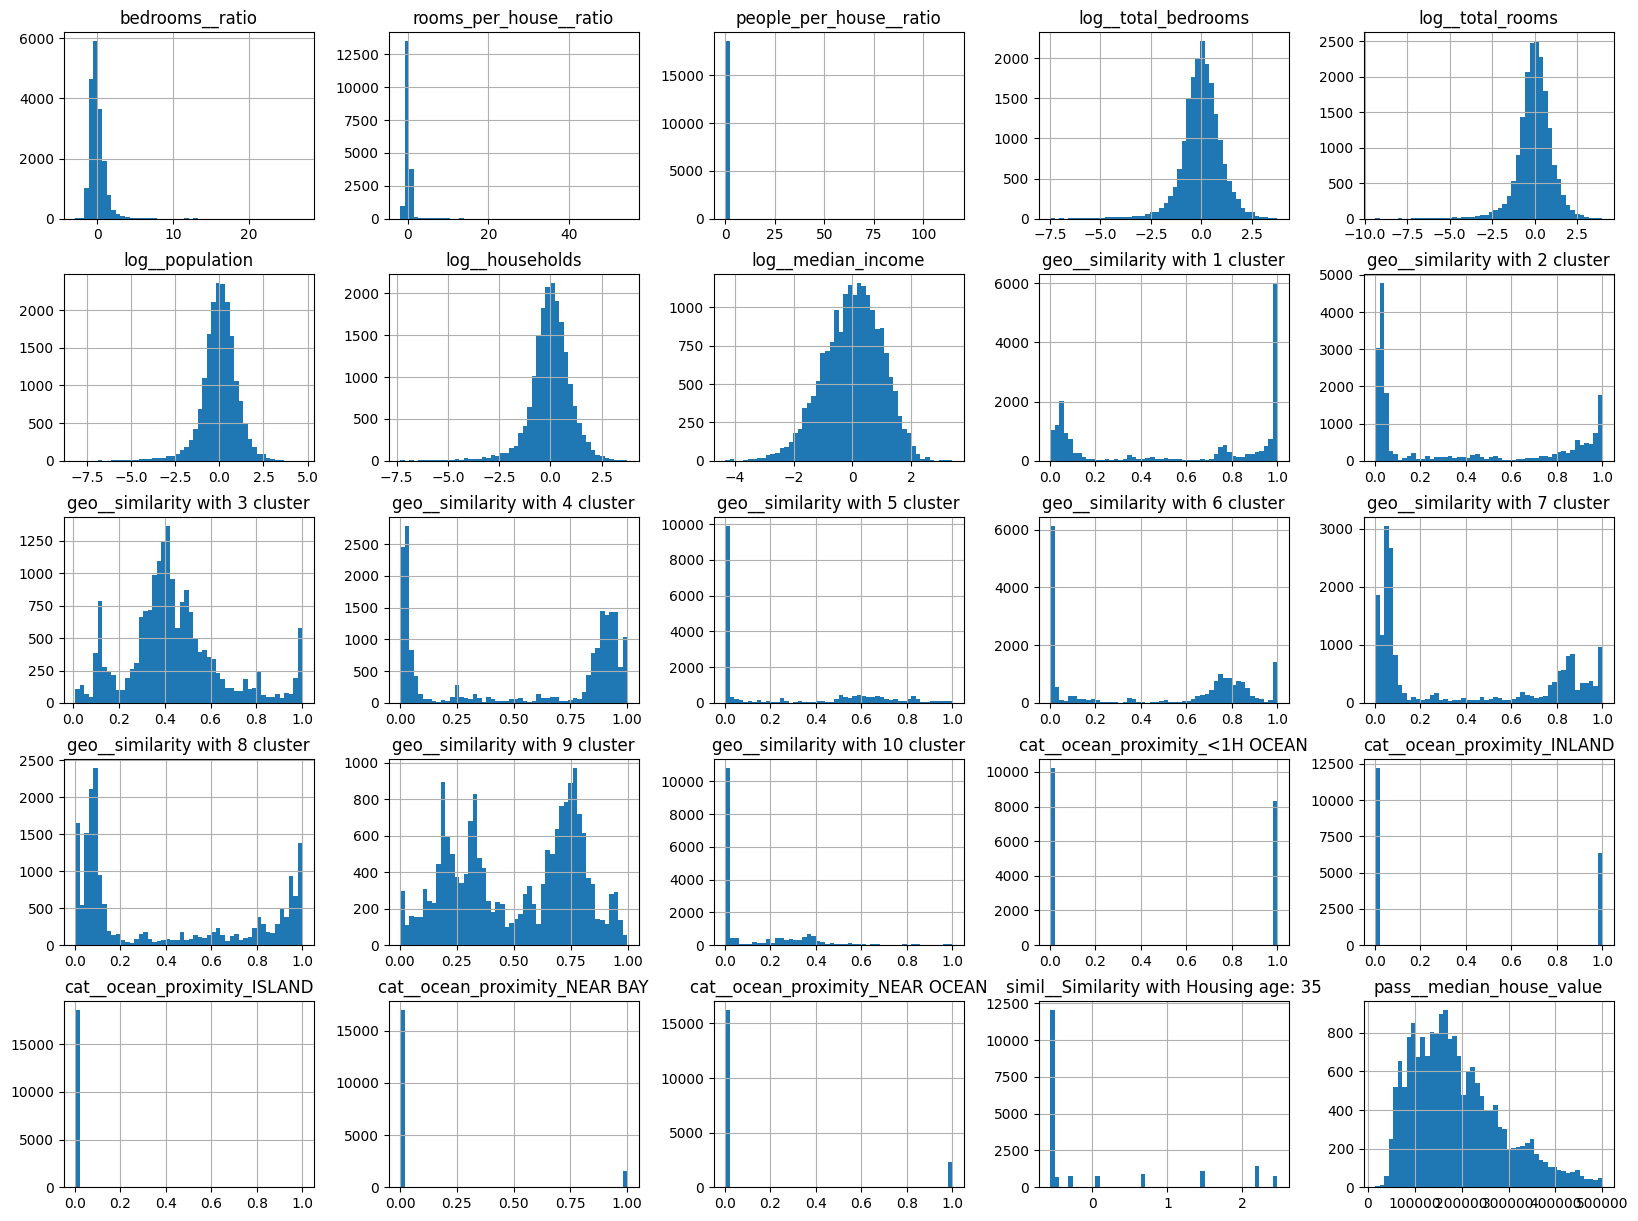

In [47]:
df.hist(bins=50,figsize=(20,15))